# End-to-end template: the 45-minute flow

The sequence you would actually type on an unfamiliar hourly dataset, from `read_csv` to "here is what I would investigate next".
Each step has a one-line **why** — the reason an interviewer cares about it.

Task for this run: **predict hourly consumption 24 hours ahead** from the messy file `hourly_power_raw.csv`.

What's in here
1. Load and inspect (shape, dtypes, NaNs, duplicates, time range, interval)
2. Clean (parse time, sort, dedupe, numeric coercion, sentinels, reindex to a full hourly grid)
3. Define the problem
4. Features (lags, shifted rolling, calendar, forecast temperature via `merge_asof`)
5. Chronological split, baselines, LinearRegression and Ridge
6. Metrics table, coefficients, residual analysis, worst errors
7. What I would investigate next + talk track

## 1. Load and inspect

**Why:** you cannot judge any later number until you know what one row is, how many there should be, and what is broken.

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True)

raw = pd.read_csv("../data/hourly_power_raw.csv")
print(raw.shape)
raw.head()

(17457, 7)


,time,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh,region
0,2023-03-30 23:00:00,28555.6,4.97,8.75,0.0,70.16,GB
1,2023-07-16 15:00:00,27602.0,21.96,6.52,523.2,23.19,GB
2,2022-12-25 16:00:00,33773.8,4.15,9.57,18.5,115.79,GB
3,2023-03-10 01:00:00,26151.0,2.06,5.83,0.0,80.50,GB
4,2023-11-09 05:00:00,24584.6,6.58,4.76,0.0,69.49,GB


In [2]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17457 entries, 0 to 17456
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             17457 non-null  object 
 1   consumption_mwh  17457 non-null  float64
 2   temp_c           17308 non-null  float64
 3   wind_ms          17457 non-null  float64
 4   solar_wm2        17457 non-null  float64
 5   price_eur_mwh    17457 non-null  object 
 6   region           17457 non-null  object 
dtypes: float64(4), object(3)
memory usage: 954.8+ KB


`time` is a string and `price_eur_mwh` is `object` — something non-numeric is in there. `region` may be constant. Check NaNs, duplicates and cardinality in one go.

In [3]:
print(pd.DataFrame({"n_missing": raw.isna().sum(), "n_unique": raw.nunique(), "dtype": raw.dtypes}))
print("\nfull-row duplicates:", raw.duplicated().sum(), "| duplicated timestamps:", raw["time"].duplicated().sum())
print("non-numeric price values:", raw.loc[pd.to_numeric(raw["price_eur_mwh"], errors="coerce").isna(), "price_eur_mwh"].unique())

                 n_missing  n_unique    dtype
time                     0     17442   object
consumption_mwh          0     16497  float64
temp_c                 149      2844  float64
wind_ms                  0      1366  float64
solar_wm2                0      4062  float64
price_eur_mwh            0      9932   object
region                   0         1   object

full-row duplicates: 15 | duplicated timestamps: 15
non-numeric price values: ['missing']


In [4]:
raw.describe().round(2)

,consumption_mwh,temp_c,wind_ms,solar_wm2
count,17457.00,17308.00,17457.00,17457.00
mean,29315.46,6.27,7.30,97.73
std,4208.58,61.13,2.50,155.44
min,18092.90,-999.00,0.00,0.00
25%,26446.50,4.45,5.56,0.00
50%,29671.30,9.92,7.23,0.00
75%,32374.40,15.32,8.96,143.10
max,40824.90,27.74,15.99,794.60


`temp_c` min of −999 is a sentinel, not a temperature. **Why:** a sentinel left in the data silently wrecks means, scalers and regressions; `describe()` is the cheapest way to catch it.

## 2. Clean

**Why:** every later `shift(24)` assumes a sorted, unique, gap-free hourly grid. Build that grid explicitly instead of hoping.

In [5]:
df = raw.copy()
df["time"] = pd.to_datetime(df["time"], utc=True)          # state the timezone explicitly
df["price_eur_mwh"] = pd.to_numeric(df["price_eur_mwh"], errors="coerce")
df.loc[df["temp_c"] <= -900, "temp_c"] = np.nan
df = df.drop(columns="region")                             # constant, carries no information
df = df.sort_values("time").drop_duplicates()              # exact duplicate rows
print("remaining duplicated timestamps:", df["time"].duplicated().sum())
print("time range:", df["time"].min(), "->", df["time"].max())
print("interval counts:", df["time"].diff().value_counts().head(4).to_dict())

remaining duplicated timestamps: 0
time range: 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00
interval counts: {Timedelta('0 days 01:00:00'): 17387, Timedelta('0 days 02:00:00'): 52, Timedelta('1 days 01:00:00'): 1, Timedelta('0 days 03:00:00'): 1}


Gaps exist (2h, 3h, 25h steps). Reindex onto the full hourly grid so `shift(k)` means k hours everywhere; the gaps become NaN rows, which the final `dropna` removes from training rather than letting a lag silently point at the wrong hour.

**Interview check:** "Why not interpolate the gaps?" → Interpolating the *target* fabricates data you then evaluate on; interpolating a slow *feature* like temperature over 1–2 hours is defensible. Decide per column and say so.

In [6]:
full_idx = pd.date_range(df["time"].min(), df["time"].max(), freq="h")
d = df.set_index("time").reindex(full_idx)
d.index.name = "time"
print("grid rows:", len(d), "| rows with missing consumption:", d["consumption_mwh"].isna().sum())
print("longest gap (hours):", d["consumption_mwh"].isna().astype(int).groupby(d["consumption_mwh"].notna().cumsum()).sum().max())
d["temp_c"] = d["temp_c"].interpolate(limit=3)             # short gaps in a smooth exogenous variable only
d.loc["2022-03-26 22:00":"2022-03-28 01:00"].head(6)

grid rows: 17520 | rows with missing consumption: 78
longest gap (hours): 24


,consumption_mwh,temp_c,wind_ms,solar_wm2,price_eur_mwh
time,,,,,
2022-03-26 22:00:00+00:00,29131.0,5.7600,6.97,0.0,115.30
2022-03-26 23:00:00+00:00,27526.1,4.4600,5.17,0.0,93.66
2022-03-27 00:00:00+00:00,NaN,4.4972,NaN,NaN,NaN
2022-03-27 01:00:00+00:00,NaN,4.5344,NaN,NaN,NaN
2022-03-27 02:00:00+00:00,NaN,4.5716,NaN,NaN,NaN
2022-03-27 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN


## 3. Define the problem

> Decision at hour **t**, using data with timestamp ≤ t, predict `consumption_mwh` at **t + 24**.

The frame is indexed by the **target hour τ**; every feature is shifted by ≥ 24 so it was known at τ − 24. Temperature at τ is *not* known at τ − 24, so we use the forecast issued at or before τ − 24.

**Why:** an interviewer wants to hear the decision time and horizon *before* the first feature is written. It is the only way to judge leakage later.

## 4. Features

**Why `shift(24).rolling(24)`:** the window must end at the decision time τ − 24, not at τ.

In [7]:
H = 24
y = d["consumption_mwh"]
F = pd.DataFrame({
    "y": y,
    "lag24": y.shift(H),                                    # last observation at decision time
    "lag48": y.shift(48),
    "lag168": y.shift(168),                                 # same hour last week
    "roll24_mean": y.shift(H).rolling(24, min_periods=20).mean(),     # 24h mean ending at decision time
    "roll168_mean": y.shift(H).rolling(168, min_periods=150).mean(),  # tolerate a few missing hours in the window
    "temp_lag24": d["temp_c"].shift(H),                     # last observed temperature
    "price_lag24": d["price_eur_mwh"].shift(H),
})
F["hour"], F["dow"], F["month"] = F.index.hour, F.index.dayofweek, F.index.month
F["hour_sin"], F["hour_cos"] = np.sin(2*np.pi*F["hour"]/24), np.cos(2*np.pi*F["hour"]/24)
F["is_weekend"] = (F["dow"] >= 5).astype(int)
F["decision_time"] = F.index - pd.Timedelta(hours=H)
F[["y", "lag24", "roll24_mean", "temp_lag24", "decision_time"]].iloc[200:203]

,y,lag24,roll24_mean,temp_lag24,decision_time
time,,,,,
2022-01-09 08:00:00+00:00,31403.5,33030.7,32864.656522,-1.33,2022-01-08 08:00:00+00:00
2022-01-09 09:00:00+00:00,31538.0,32710.7,32667.600000,0.47,2022-01-08 09:00:00+00:00
2022-01-09 10:00:00+00:00,30468.2,32335.1,32653.745833,1.39,2022-01-08 10:00:00+00:00


**Pitfall: gaps are amplified by rolling windows.** `rolling(168)` returns NaN if *any* hour in the window is missing, so 78 missing hours become thousands of unusable rows. Count what you lose at every step; `min_periods` is the usual fix.

In [8]:
strict = y.shift(H).rolling(168).mean()
print("rows lost to a strict rolling(168):", strict.isna().sum(), "| with min_periods=150:", F["roll168_mean"].isna().sum())
print("NaN count per feature:"); print(F.isna().sum().sort_values(ascending=False).head(6).to_frame().T)

rows lost to a strict rolling(168): 7440 | with min_periods=150: 329
NaN count per feature:
   roll168_mean  lag168  price_lag24  lag48  lag24  roll24_mean
0           329     246          202    126    102           82


**Forecast temperature for the target hour, as known at decision time.** `merge_asof` picks, for each target hour (`by=`), the forecast with the latest `origin_datetime ≤ decision_time`.

**Why:** using the *measured* temperature at τ would be the single most common leak in this kind of exercise.

In [9]:
fc = pd.read_csv("../data/weather_forecasts.csv", parse_dates=["origin_datetime", "forecast_datetime"])
fc = fc.rename(columns={"forecast_datetime": "time"}).sort_values("origin_datetime")

F = pd.merge_asof(
    F.reset_index().sort_values("decision_time"),
    fc[["origin_datetime", "time", "horizon_h", "temp_forecast_c"]],
    left_on="decision_time", right_on="origin_datetime", by="time", direction="backward",
).set_index("time").sort_index()

print("forecast horizons used:", F["horizon_h"].min(), "-", F["horizon_h"].max())
assert (F["origin_datetime"].dropna() <= F.loc[F["origin_datetime"].notna(), "decision_time"]).all()
F["temp_fc_heating"] = np.clip(15 - F["temp_forecast_c"], 0, None)   # heating-degree feature: demand is non-linear in temp
print("rows before dropna:", len(F), "| after:", len(F.dropna()))

forecast horizons used: 24.0 - 35.0
rows before dropna: 17520 | after: 16840


## 5. Split, baselines, models

Chronological split, train = 2022, test = 2023, with a **24-row gap** so no training target lies after the first test decision time.

**Why baselines:** an R² of 0.9 means nothing until you know the seasonal naive gets 0.85.

In [10]:
F = F.dropna()
train = F.loc[: "2022-12-30 23:00"]                          # leaves a 24h gap before 2023-01-01
test  = F.loc["2023-01-01":]
print(len(train), "train |", len(test), "test |", "gap hours:", (test.index[0] - train.index[-1]) / pd.Timedelta(hours=1))

seasonal = train.groupby(["hour", "dow"])["y"].mean().rename("seasonal")
preds = pd.DataFrame({
    "naive: same hour yesterday": test["lag24"],
    "naive: same hour last week": test["lag168"],
    "seasonal mean (train)": test.join(seasonal, on=["hour", "dow"])["seasonal"],
}, index=test.index)

8215 train | 8601 test | gap hours: 25.0


In [11]:
features = ["lag24", "lag48", "lag168", "roll24_mean", "roll168_mean",
            "temp_forecast_c", "temp_fc_heating", "price_lag24", "hour_sin", "hour_cos", "is_weekend"]

lr = LinearRegression().fit(train[features], train["y"])
preds["LinearRegression"] = lr.predict(test[features])

ridge = make_pipeline(StandardScaler(), Ridge(alpha=10.0)).fit(train[features], train["y"])   # scaler inside the pipeline
preds["Ridge(alpha=10)"] = ridge.predict(test[features])

## 6. Results

**Why a table, not one number:** RMSE vs MAE tells you about tails; bias tells you about a systematic shift; MASE < 1 tells you that you beat naive.

In [12]:
naive_mae_train = np.mean(np.abs(train["y"] - train["lag24"]))
def metrics(y_true, y_pred):
    e = y_true - y_pred
    return pd.Series({"RMSE": np.sqrt(np.mean(e**2)), "MAE": np.mean(np.abs(e)), "bias": e.mean(),
                      "MASE": np.mean(np.abs(e)) / naive_mae_train, "R2": r2_score(y_true, y_pred)})
table = pd.DataFrame({k: metrics(test["y"], v) for k, v in preds.items()}).T.sort_values("RMSE")
table.round(3)

,RMSE,MAE,bias,MASE,R2
Ridge(alpha=10),1061.336,845.160,-36.601,0.602,0.936
LinearRegression,1061.459,845.306,-38.487,0.602,0.936
naive: same hour last week,1588.408,1237.337,-10.427,0.882,0.856
naive: same hour yesterday,1696.733,1333.456,-4.015,0.950,0.835
seasonal mean (train),2119.894,1794.351,-107.365,1.278,0.743


In [13]:
# in-sample vs out-of-sample gap
print("LR   in-sample R2 %.4f   out-of-sample R2 %.4f" % (r2_score(train["y"], lr.predict(train[features])), table.loc["LinearRegression", "R2"]))
print("Ridge in-sample R2 %.4f   out-of-sample R2 %.4f" % (r2_score(train["y"], ridge.predict(train[features])), table.loc["Ridge(alpha=10)", "R2"]))

LR   in-sample R2 0.9387   out-of-sample R2 0.9355
Ridge in-sample R2 0.9387   out-of-sample R2 0.9355


**Coefficients.** Read them for *sign and plausibility*, not for importance (units differ). For comparable magnitudes use the Ridge coefficients on standardised features.

**Interview check:** "Does the sign on `temp_forecast_c` make sense?" With `temp_fc_heating` also in the model the two share the effect, so read them together.

In [14]:
coefs = pd.DataFrame({
    "LR (raw units)": pd.Series(lr.coef_, index=features),
    "Ridge (per 1 sd)": pd.Series(ridge[-1].coef_, index=features),
}).sort_values("Ridge (per 1 sd)")
print("LR intercept: %.0f" % lr.intercept_)
coefs.round(2)

LR intercept: 15971


,LR (raw units),Ridge (per 1 sd)
roll24_mean,-0.45,-997.82
is_weekend,-1619.48,-726.85
hour_cos,-543.81,-386.93
hour_sin,-506.65,-359.60
temp_forecast_c,-35.43,-260.96
roll168_mean,-0.03,-63.35
price_lag24,1.58,54.94
temp_fc_heating,171.09,965.58
lag168,0.28,1183.48
lag48,0.30,1264.27


**Residuals by hour and month.** Positive error = under-prediction. A pattern here is a missing feature, not noise.

In [15]:
ev = test[["y", "hour", "dow", "month", "temp_forecast_c"]].copy()
ev["pred"] = preds["LinearRegression"]
ev["err"] = ev["y"] - ev["pred"]

def profile(col):
    g = ev.groupby(col)["err"]
    return pd.DataFrame({"bias": g.mean(), "rmse": g.apply(lambda e: np.sqrt(np.mean(e**2)))}).T.round(0)

print("by hour of day"); print(profile("hour"))
print("\nby month"); print(profile("month"))

by hour of day
hour      0       1       2       3       4       5       6       7       8       9       10     11     12     13  \
bias   -95.0  -134.0  -146.0  -152.0  -158.0  -101.0   -28.0   120.0   175.0   149.0    84.0  -27.0 -126.0 -219.0   
rmse  1083.0  1076.0  1104.0  1064.0  1055.0  1084.0  1086.0  1034.0  1067.0  1062.0  1052.0  958.0  933.0  965.0   

hour      14      15      16      17      18      19      20      21      22      23  
bias  -258.0  -285.0   -97.0    68.0   205.0   165.0    76.0    12.0   -73.0   -66.0  
rmse  1040.0  1130.0  1072.0  1121.0  1053.0  1036.0  1037.0  1094.0  1152.0  1087.0  

by month
month      1       2       3       4       5      6      7      8      9       10      11      12
bias    -19.0   -82.0    11.0  -184.0  -113.0 -121.0    3.0   21.0  -17.0   111.0    23.0  -104.0
rmse   1126.0  1172.0  1052.0  1227.0  1084.0  944.0  857.0  946.0  929.0  1119.0  1070.0  1154.0


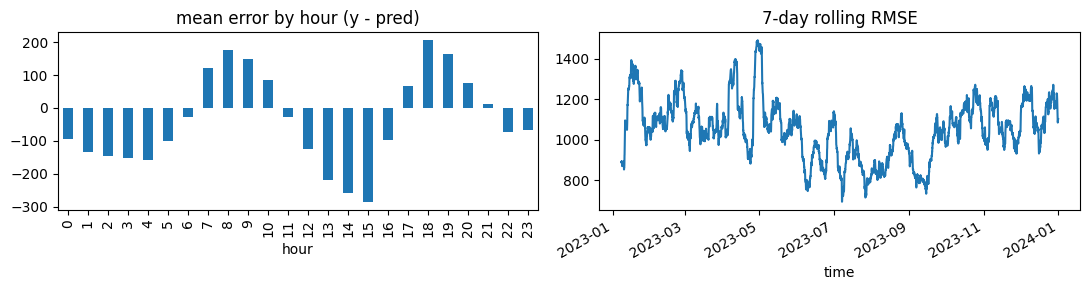

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ev.groupby("hour")["err"].mean().plot(kind="bar", ax=ax[0], title="mean error by hour (y - pred)")
ev["err"].rolling(24*7).apply(lambda e: np.sqrt(np.mean(e**2))).plot(ax=ax[1], title="7-day rolling RMSE")
plt.tight_layout()

**Worst errors.** Look at the actual rows: are they holidays, data errors, weather extremes, or a forecast bust? Each has a different fix.

In [17]:
worst = ev.reindex(ev["err"].abs().sort_values(ascending=False).index).head(8)
worst["temp_actual"] = d["temp_c"].reindex(worst.index)      # hindsight only — for diagnosis, never as a feature
worst.round(1)

,y,hour,dow,month,temp_forecast_c,pred,err,temp_actual
time,,,,,,,,
2023-04-05 22:00:00+00:00,25556.0,22,2,4,5.2,30474.0,-4918.0,14.0
2023-04-26 06:00:00+00:00,24118.5,6,2,4,10.4,28114.0,-3995.5,12.7
2023-01-16 02:00:00+00:00,30917.1,2,0,1,-2.9,26945.9,3971.2,-5.6
2023-04-26 03:00:00+00:00,20536.9,3,2,4,10.2,24367.2,-3830.3,11.2
2023-02-20 06:00:00+00:00,28532.0,6,0,2,-3.2,32348.1,-3816.1,1.8
2023-01-10 22:00:00+00:00,36074.4,22,1,1,-6.5,32295.9,3778.5,-4.4
2023-11-05 15:00:00+00:00,31387.8,15,6,11,12.5,27625.5,3762.3,7.4
2023-10-11 08:00:00+00:00,34715.8,8,2,10,9.2,30989.2,3726.6,8.1


In [18]:
# is the error concentrated? share of squared error from the worst 1% of hours
se = ev["err"]**2
print("share of total squared error from worst 1%% of hours: %.1f%%" % (100 * se.nlargest(int(len(se)*0.01)).sum() / se.sum()))
print("error autocorrelation lag 1 / 24:", round(ev["err"].autocorr(1), 3), "/", round(ev["err"].autocorr(24), 3))

share of total squared error from worst 1% of hours: 9.0%
error autocorrelation lag 1 / 24: 0.714 / 0.015


Strongly autocorrelated residuals (lag-1 ≈ 0.7+) mean the last known error carries information: at decision time τ − 24 the residual for target τ − 24 *is* known, so `err.shift(24)` is a legitimate feature and would tighten the forecast. That is the first thing to try next.

## 7. What I would investigate next

- **Residual autocorrelation** → add the lagged residual / lagged error of the naive forecast as a feature.
- **Hourly bias pattern** → interact hour with weekend (hour × is_weekend one-hot) or fit separate models per hour.
- **Monthly bias** → the trend in demand; add a slow time trend or a rolling 30-day mean level.
- **Non-linearity in temperature** → check `err` vs `temp_forecast_c` in bins; add cooling-degree term.
- **Holidays** — likely in the worst-error list; a public-holiday flag is cheap.
- **Forecast vintage** — with a 12-hourly forecast cycle, horizons 24–35h; does the error grow with `horizon_h`?
- **Walk-forward refit** monthly instead of one fit on 2022; check whether the 2023 bias disappears.
- **The gap days** — was 2022-03-27 (DST change) really missing, or is there a timezone problem in the source?
- **Stability** — per-month RMSE for every change; a change that wins 7/12 months is not a win.

## Talk track

Sentences to say out loud at each stage — they show the interviewer what you are checking and why.

- "Before I look at any metric I want to know what one row is, whether timestamps are unique, and whether the interval is constant."
- "`price` came in as object, so something non-numeric is in there; I'll coerce and count what I lose rather than dropping blind."
- "A minimum of −999 in temperature is a sentinel. If I leave it in, the scaler and the regression both see a −1000 °C hour."
- "There are gaps. I'll reindex onto a full hourly grid so `shift(24)` is always 24 hours, and let `dropna` remove the rows around gaps."
- "The problem is: decision at t, predict consumption at t + 24. Everything I use has to have a timestamp ≤ t."
- "That means the temperature at the target hour isn't available; I'll use the forecast that had been issued by t, matched with `merge_asof`."
- "The rolling mean needs a `shift` first so the window ends at the decision time, not at the target."
- "Split is chronological with a 24-hour gap. Shuffling would put neighbours of each test row in train."
- "Before the model, the baselines: same hour yesterday, same hour last week, seasonal mean from train. Anything I build has to beat these."
- "R² of 0.92 vs 0.86 for the naive — good, but let me check the in-sample gap and where the errors are."
- "The residual by hour has a shape, so there's a missing interaction; the residual autocorrelation is high, so a lagged error would help."
- "The worst errors are a few specific days; I'd look at whether those are holidays or data problems before touching the model."
- "If I changed one thing next it would be X, and I'd judge it by per-month RMSE, not by the annual number."